Exercise 1:

Abstract: The Wine dataset contains chemical analysis results of wines derived from three different cultivars, with multiple features representing chemical properties such as alcohol content, ash, and flavonoids. In such datasets, some observations may significantly differ from the general pattern of the data. Apply the k-Nearest Neighbours (k-NN) algorithm to analyze the dataset by computing the distances between data points and their nearest neighbors. Identify observations that show unusually large distances compared to neighboring points and classify them as anomalies. Visualize the detected anomalies to understand the distribution of normal and abnormal observations in the dataset.

Dataset: UCI Repository link: https://archive.ics.uci.edu/ml/datasets/wine

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [26]:
file_path = "/content/wine.data"

In [27]:
columns = ['class'] + [f'feature_{i}' for i in range(13)]
df = pd.read_csv(file_path, header=None, names=columns)

In [28]:
X = df.iloc[:, 1:].values

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
k = 5
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_scaled)

NearestNeighbors()

In [31]:
distances, _ = knn.kneighbors(X_scaled)
kth_distance = distances[:, -1]

In [32]:
threshold = np.percentile(kth_distance, 95)

In [33]:
outlier_indices = np.where(kth_distance > threshold)[0]
outliers = X_scaled[outlier_indices]

print("Outliers detected:", len(outlier_indices))

Outliers detected: 9


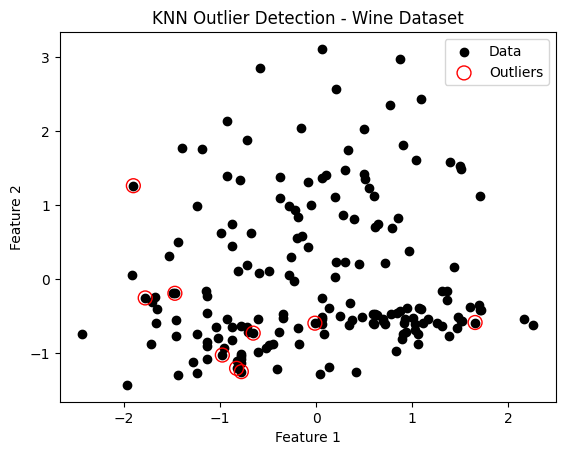

In [34]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color='black', label='Data')

plt.scatter(outliers[:, 0], outliers[:, 1],
            edgecolors='red', facecolors='none',
            s=100, label='Outliers')

plt.title("KNN Outlier Detection - Wine Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Exercise 2:

Abstract: The Breast Cancer Wisconsin dataset contains features computed from digitized images of breast mass samples, describing characteristics such as radius, texture, smoothness, and compactness. Variations in these features may indicate abnormal patterns in the dataset. Apply the k-Nearest Neighbours (k-NN) algorithm to analyze the dataset by measuring the distance between data points and their nearest neighbors. Identify observations that deviate significantly from the majority of the data and classify them as anomalies. Visualize the detected anomalies to interpret the distribution of normal and
abnormal data points.

Dataset: UCI Repository link: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [36]:
file_path = "/content/wdbc.data"

In [37]:
columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(30)]
df = pd.read_csv(file_path, header=None, names=columns)

In [38]:
X = df.iloc[:, 2:].values

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
k = 5
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_scaled)

NearestNeighbors()

In [41]:
distances, _ = knn.kneighbors(X_scaled)
kth_distance = distances[:, -1]

In [42]:
threshold = np.percentile(kth_distance, 90)

In [43]:
outlier_indices = np.where(kth_distance > threshold)[0]
outliers = X_scaled[outlier_indices]
print("Outliers detected:", len(outlier_indices))

Outliers detected: 57


In [44]:
from sklearn.decomposition import PCA

In [45]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [46]:
outliers_pca = X_pca[outlier_indices]

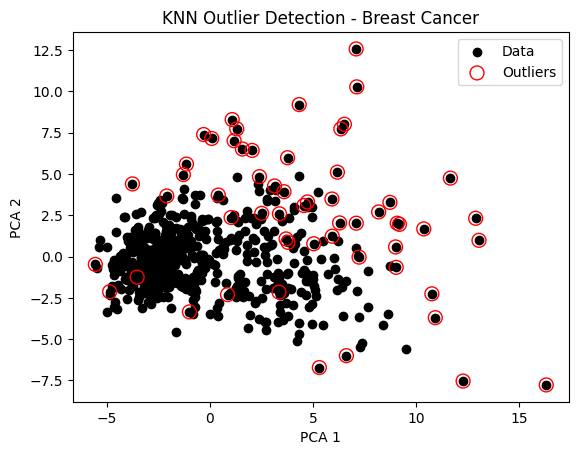

In [47]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='black', label='Data')

plt.scatter(outliers_pca[:, 0], outliers_pca[:, 1],
            edgecolors='red', facecolors='none',
            s=100, label='Outliers')

plt.title("KNN Outlier Detection - Breast Cancer")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()